In [1]:
# Task 1 - Part A
# Traditional CNN using CIFAR-10 Dataset

import tensorflow as tf #Builds and trains learing models
from tensorflow.keras import datasets,layers,models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [2]:
(Data_1, Data_2), (Test_Data1, Test_Data2) = datasets.cifar10.load_data() #Will automatically download datasets

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4562s 27us/step


In [3]:
print("Training Images Shape :", Data_1.shape) #Dimensions of the Training data
print("Training Labels Shape :", Data_2.shape) #Number of Training label

print("Testing Images Shape :", Test_Data1.shape) #Dimensions of Testing data
print("Testing Labels Shape :", Test_Data2.shape) #Each image has 1 correct label

Training Images Shape : (50000, 32, 32, 3)
Training Labels Shape : (50000, 1)
Testing Images Shape : (10000, 32, 32, 3)
Testing Labels Shape : (10000, 1)


In [ ]:
class_names = [
    "Airplane", "Automobile", "Bird", "Cat", "Deer",
    "Dog", "Frog", "Horse", "Ship", "Truck"
]
plt.figure(figsize=(8, 8)) #Set figure size 8*8 inches
for i in range(9): # Loops from 0 to 9(Totally 10 datasets)
    plt.subplot(3, 3, i + 1) #Figure is splited into 3*3 grid
    plt.imshow(Data_1[i]) #Displays training datasets
    plt.title(class_names[Data_2[i][0]]) #Displays class names above the images
    plt.axis("off")#Removes x & y axis
plt.tight_layout() #Spacing btw images are adjusted
plt.show() #Displays figure

In [5]:
Data_1 = Data_1.astype("float32") / 255.0 #Image pixels are converted to float from integers (Normalisation of training data)
Test_Data1 = Test_Data1.astype("float32") / 255.0 #Normalisation of Testing data

In [6]:
Data_1, Data1_val, Data_2, Data2_val = train_test_split (
    Data_1,
    Data_2,
    test_size=0.1, #10% of the training data is used as the validation set
    random_state=42, #Fixs the random split
    stratify=Data_2 #Keeps Class distribution balanced
)#Splits 1 dataset into 2 parts

In [7]:
print("Training Images :", Data_1.shape)
print("Validation Images :", Data1_val.shape) #Validation set
print("Testing Images :", Test_Data1.shape)

Training Images : (45000, 32, 32, 3)
Validation Images : (5000, 32, 32, 3)
Testing Images : (10000, 32, 32, 3)


In [8]:
# Traditional CNN model
model = models.Sequential() #Adds layers sequential
#New layer adding
model.add(layers.Conv2D(64, (3,3), activation='relu',
                        padding='same',
                        input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))# Filter 64 ,(3,3)pixel ,relu(Keeps if greater than 0),pooling is to reduce image size
#Second layer
model.add(layers.Conv2D(128, (3,3),
                        activation='relu',
                        padding='same'))
model.add(layers.MaxPooling2D((2,2)))
#Third layer
model.add(layers.Conv2D(256, (3,3),
                        activation='relu',
                        padding='same'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten()) #Feature is maps into a single vector
model.add(layers.Dense(512, activation='relu')) # Makes fully Connected Layer
model.add(layers.Dense(10, activation='softmax')) #Output Layer(10 output class)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# Preparing model for training
model.compile(
    optimizer='adam', #Helps the CNN improve itself
    loss='sparse_categorical_crossentropy', #Shows how wrong the model's predictions are (integers from 0 to 9)
    metrics=['accuracy'] #Shows how well the model is performing withe percentage
)

In [13]:
# Training the CNN model
history = model.fit(
    Data_1,
    Data_2,
    epochs=20, #CNN can see datsets 20 times
    batch_size=64, #Small batchs of 64 bits for easy learning for CNN
    validation_data=(Data1_val, Data2_val)
)#sShows graph

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 296s 420ms/step - accuracy: 0.9182 - loss: 0.2351 - val_accuracy: 0.7630 - val_loss: 0.8812
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 315s 410ms/step - accuracy: 0.9409 - loss: 0.1712 - val_accuracy: 0.7526 - val_loss: 0.9176
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 295s 420ms/step - accuracy: 0.9547 - loss: 0.1311 - val_accuracy: 0.7498 - val_loss: 1.1068
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 292s 415ms/step - accuracy: 0.9636 - loss: 0.1068 - val_accuracy: 0.7594 - val_loss: 1.0986
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 320s 412ms/step - accuracy: 0.9693 - loss: 0.0885 - val_accuracy: 0.7546 - val_loss: 1.2532
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 325s 416ms/step - accuracy: 0.9687 - loss: 0.0910 - val_accuracy: 0.7564 - val_loss: 1.2359
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 291s 413ms/step - accuracy: 0.9725 - loss: 0.0805 - val_accuracy: 0.7468 - val_loss: 1.4089
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 319s 409ms/step - accuracy: 0.9751 -

In [14]:
# Evaluate the model
Test_loss, Test_accuracy = model.evaluate(Data_1, Data_2)
print("Test Loss:", Test_loss)
print("Test Accuracy:", Test_accuracy)

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 77s 55ms/step - accuracy: 0.9851 - loss: 0.0453
Test Loss: 0.04529009014368057
Test Accuracy: 0.9850666522979736


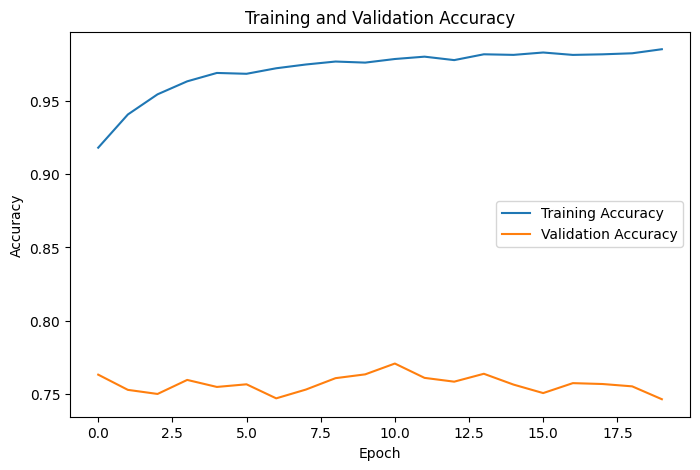

In [15]:
# Ploting accuracy graph
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

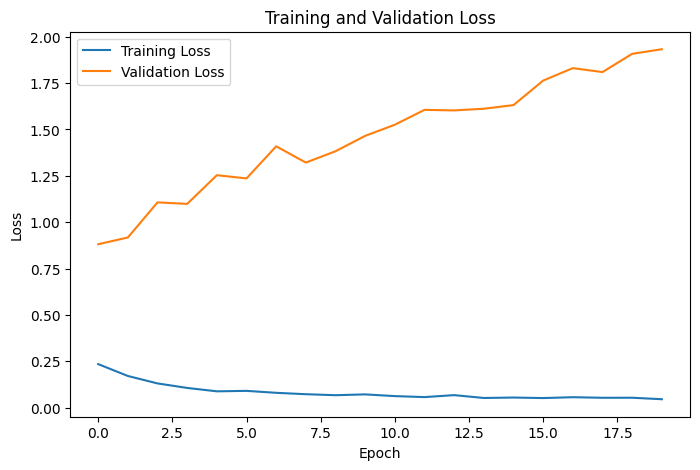

In [16]:
# Ploting loss graph
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [18]:
Data2_pro = model.predict(Test_Data1) # Class probabilities for the test dataset
Data2_pro_classes = np.argmax(Data2_pro, axis=1) # Convert probabilities to class labels
Data2_true = Test_Data2.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 64ms/step


In [19]:
CM = confusion_matrix(Data2_true, Data2_pro_classes) #Confusion matrix is generated

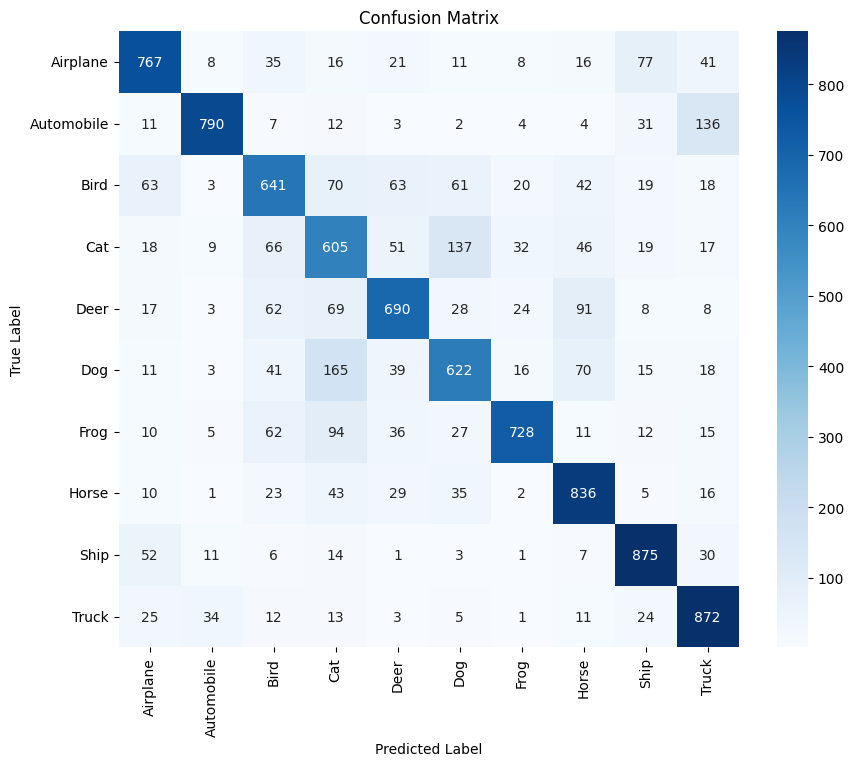

In [20]:
# Ploting confusion matrix
plt.figure(figsize=(10,8))
sns.heatmap(
    CM,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [21]:
model.save("traditional_cnn.keras") # Saved the trained model
print("Model saved successfully!")

Model saved successfully!
